<a href="https://colab.research.google.com/github/CatherineNditu/Call-Center-Analysis/blob/main/Adult_Census_Income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

 #Dataset URL
DATA_URL= \
 "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

 #Column names from UCI Adult dataset
COLUMNS=[
    "age","workclass","fnlwgt","education","maritalstatus","occupation","education_num","relationship","race","gender","capital_gain","capital_loss","country","income","hours_per_week"
]

#Load data
df=pd.read_csv(DATA_URL,header=None,names=COLUMNS,na_values="?",skipinitialspace=True)

#Basic inspection

#First 5 rows
print(df.head())
#Data structure
print(df.shape)
#Data info
print(df.info())
#Summary statistics
print(df.describe())


   age         workclass  fnlwgt  education  maritalstatus  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

           occupation      education_num   relationship   race  gender  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  country         income hours_per_week  
0          2174             0       40  United-States          <=50K  
1             0             0       13  

2. Task 2


*   Audit quality:Missing values (treat ? as missing),duplicates, inconsistent,categories(trims/standardize),outliers(IQR rule),basic transformations
*   List item



In [ ]:
import numpy as np
#Check missing values
print("Missing values per column:")
print(df.isnull().sum())

#Check duplicates
dup_count=df.duplicated().sum()
print("\nDuplicates rows:",dup_count)

#Standardize categories
for col in df.select_dtypes(include="object").columns:
  df[col]=df[col].astype(str).str.strip()

#Outlier detection
def iqr_rule(series):
  q1,q3 =series.quantile([0.25,0.75])
  iqr=q3-q1
  lower=q1-1.5*iqr
  upper=q3+1.5*iqr
  return(series<lower)|(series>upper)
outlier_summary={}
for col in df.select_dtypes(include={np.number}).columns:
  flags=iqr_rule(df[col])
  outlier_summary[col]=flags.sum()
  print("\nOutlier counts per numeric column:")
  print(outlier_summary)

#Simple transformations
df["log 1p_capital_gain"]=np.log1p(df["capital_gain"])
df["log 1p_capital_loss"]=np.log1p(df["capital_loss"])

print("\nNew transformed columns added:log1p_capital_gain,log1p_capital_loss")

Missing values per column:
age                  0
workclass         1836
fnlwgt               0
education            0
maritalstatus        0
occupation           0
education_num     1843
relationship         0
race                 0
gender               0
capital_gain         0
capital_loss         0
country              0
income             583
hours_per_week       0
dtype: int64

Duplicates rows: 24

Outlier counts per numeric column:
{'age': np.int64(143)}

Outlier counts per numeric column:
{'age': np.int64(143), 'fnlwgt': np.int64(992)}

Outlier counts per numeric column:
{'age': np.int64(143), 'fnlwgt': np.int64(992), 'maritalstatus': np.int64(1198)}

Outlier counts per numeric column:
{'age': np.int64(143), 'fnlwgt': np.int64(992), 'maritalstatus': np.int64(1198), 'capital_gain': np.int64(2712)}

Outlier counts per numeric column:
{'age': np.int64(143), 'fnlwgt': np.int64(992), 'maritalstatus': np.int64(1198), 'capital_gain': np.int64(2712), 'capital_loss': np.int64(1519)}

Out

3. Task 3
EDA & Visuals


*   Univariate,bivarate(rates not just count)
*   Multivariate(heatmap/pairplot subset)
*   Craft 5-8 insights with 1-2 lines each






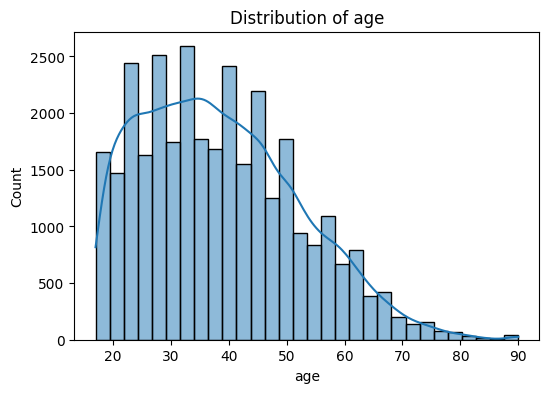

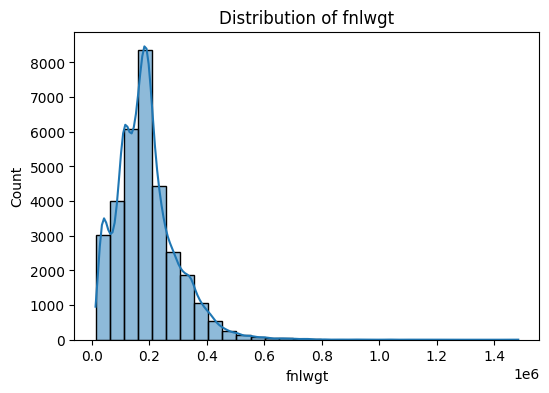

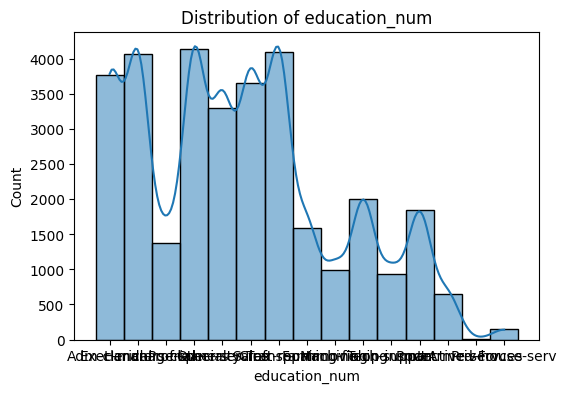

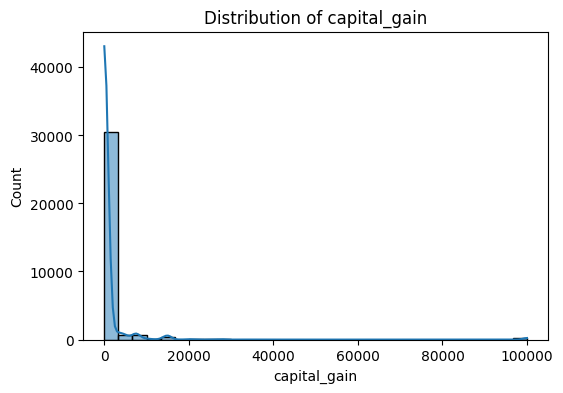

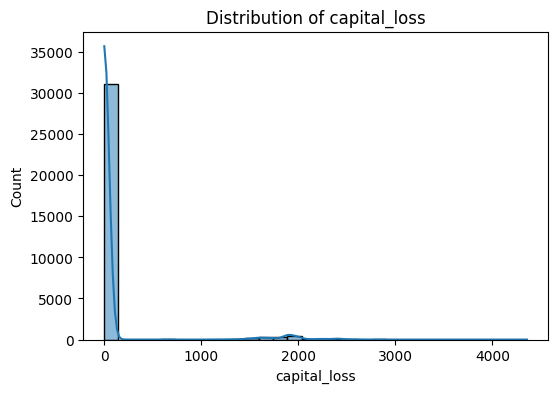

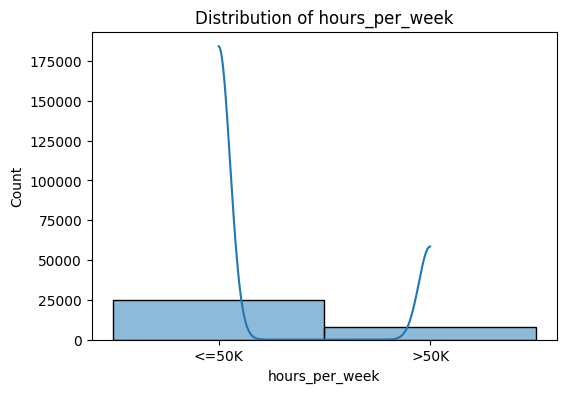

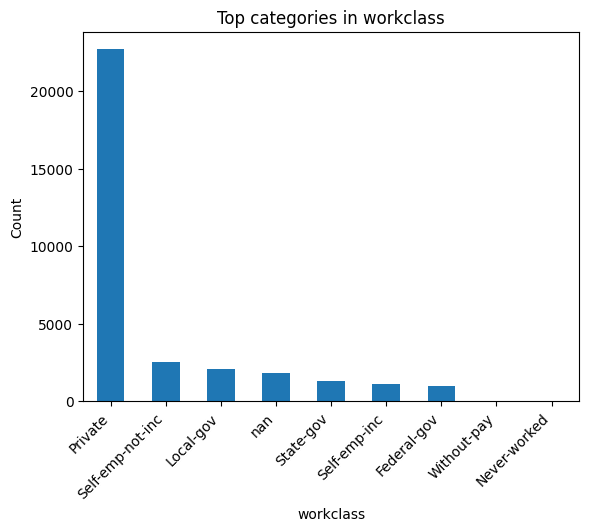

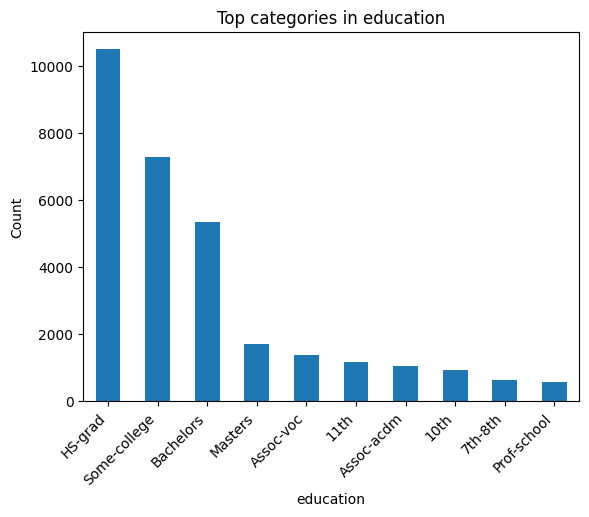

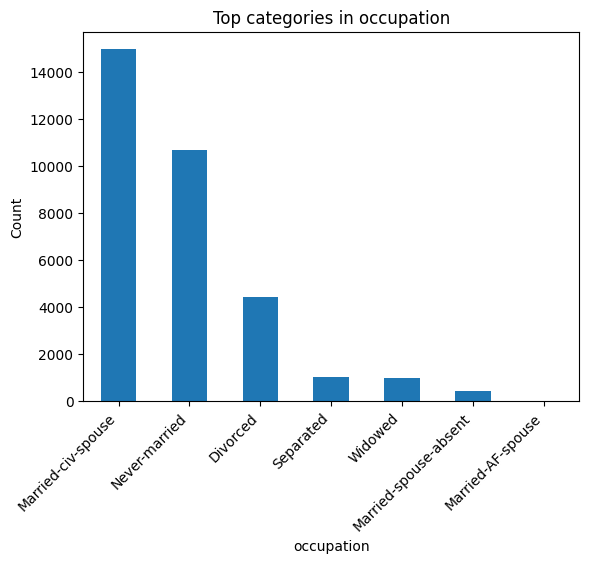

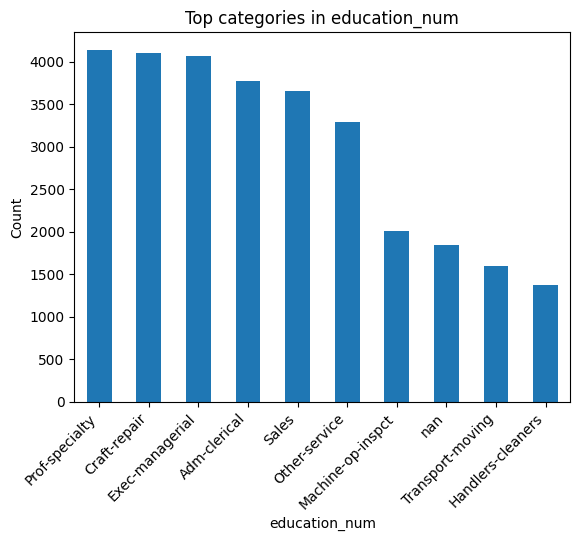

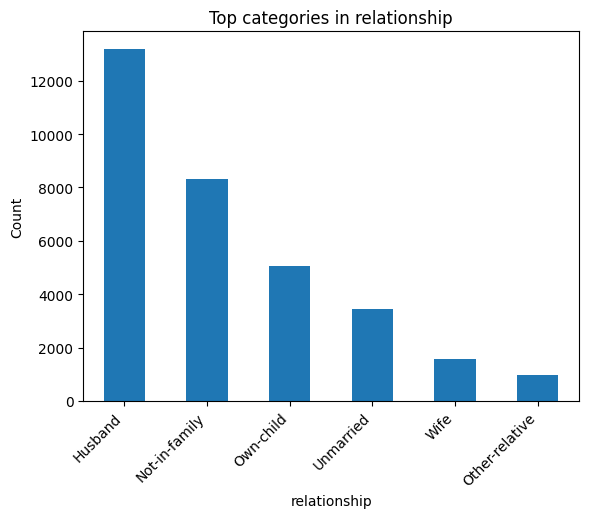

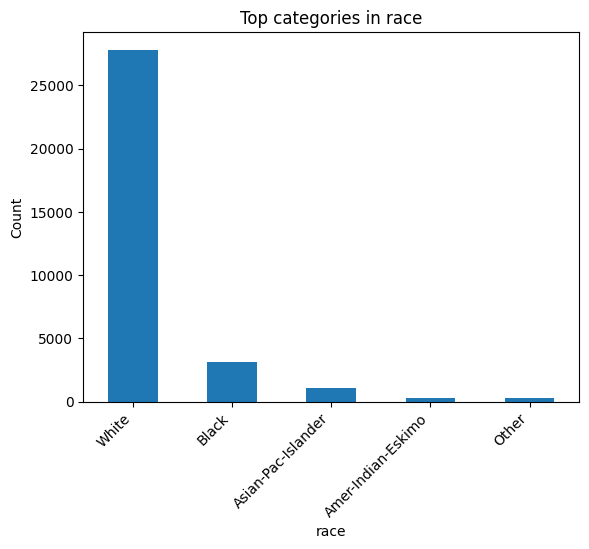

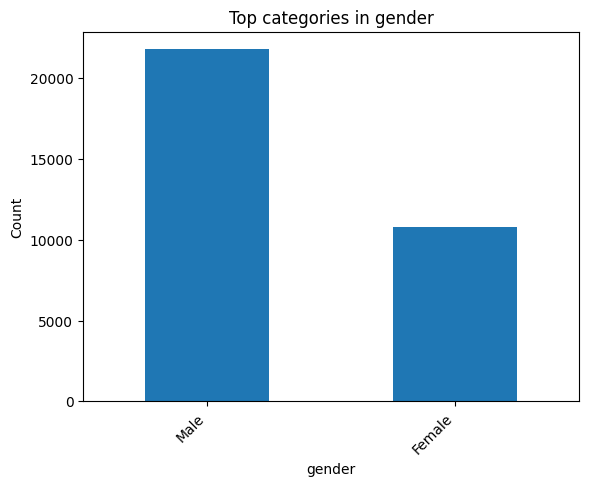

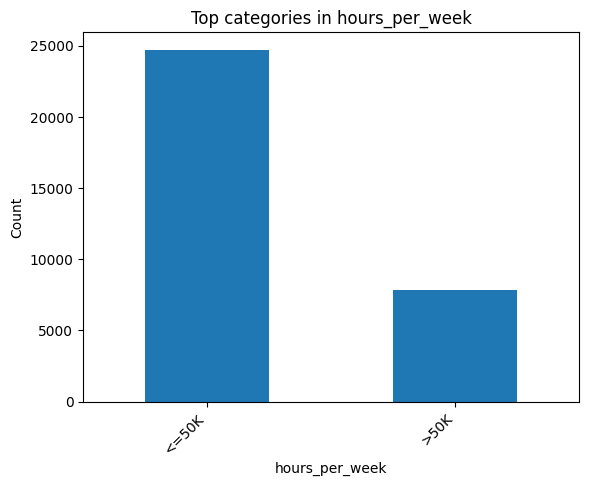

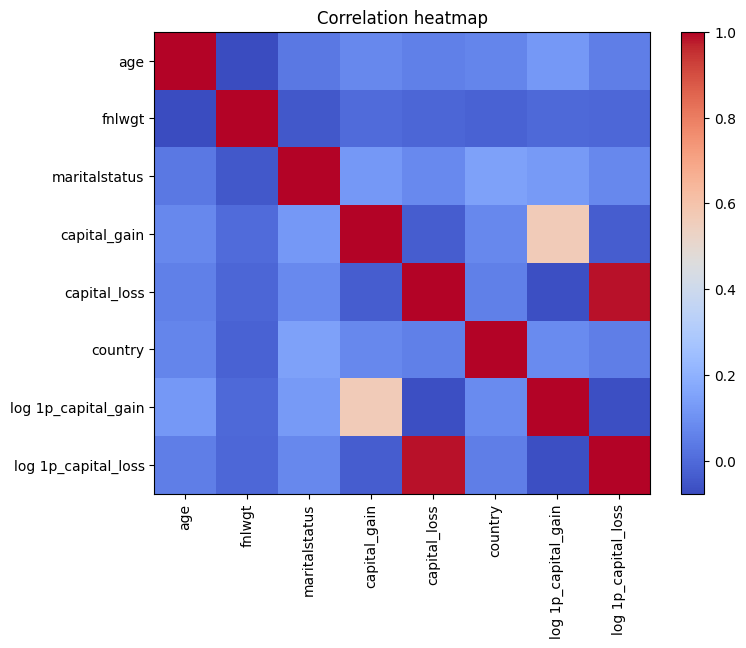

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Univariate analysis(numeric distribution)

numeric_cols=["age","fnlwgt","education_num","capital_gain","capital_loss","hours_per_week"]
for col in numeric_cols:
  plt.figure(figsize= (6,4))
  sns.histplot(df[col], bins=30, kde=True)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.show()

#Univariate analysis(categorical distribution)

cat_cols=[c for c in df.select_dtypes(include="object").columns if c!="income"]
for col in cat_cols:
  plt.figure()
  df[col].value_counts().head(10).plot(kind="bar")
  plt.title(f"Top categories in {col}")
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.xticks(rotation=45,ha="right")
  plt.show()

#Bivariate analysis(income vs categorical)
def income_rate_by(col):
  return df.groupby(col)["income"].apply(lambda x:(x== ">50K").mean()).sort_values(ascending=False)
  key_cats=["sex","education","maritalstatus","relationship","workclass","race","nativecountry","occupation"]
  for col in key_cats:
    rate=income_rate_by(col)
    plt.figure
    rate.plot(kind="bar")
    plt.title(f"Proportion earning >50k by {col}")
    plt.ylabel("Proportion >50k ")
    plt.xticks(rotation=45,ha="right")
    plt.show()

#Multivariate analysis

corr=df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(8,6))
plt.imshow(corr,cmap="coolwarm",aspect="auto")
plt.colorbar()
plt.title("Correlation heatmap")
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.show()
